# Vision-Language Model for Preliminary Clinical Image Analysis

**A preliminary clinical imaging assistant built on SmolVLM-Instruct, for free-tier Google Colab.**

---

> ### ⚠️ Educational and research use only
>
> This project is for educational and research purposes only. The model is **not a medical
> device** and must not be used as a substitute for professional medical diagnosis,
> treatment, or clinical decision-making. Every output below is generated by a
> general-purpose vision-language model that has **not** been trained, validated or
> regulated for clinical use. Nothing it produces is a diagnosis.

---

## 1.1 Objective

Select an open-source vision-language model that runs inside free-tier Colab, load it with
appropriate memory optimisations, and build a reusable inference pipeline that describes
visible features in medical images while refusing to give a diagnosis.

## 1.2 Assignment requirements

| # | Requirement | Where |
|---|---|---|
| 1 | Explain why the model was chosen | §2 |
| 2 | Load with memory optimisations | §5 |
| 3 | Reusable inference function | §7 |
| 4 | Clinical imaging system prompt | §6 |
| 5 | Inference on ≥ 2 public medical images | §8, §9 |
| 6 | Display images and outputs | §8, §9, §10 |
| 7 | Limitations and ethics | §12 |

## 1.3 What a vision-language model is

A vision-language model (VLM) joins an image encoder to a language model. The encoder
turns an image into a sequence of embeddings; a projection layer maps those into the
language model's token space; the language model then attends over image tokens and text
tokens together and generates text. That is what lets you ask a question *about* a picture
in natural language.

SmolVLM follows this pattern: a SigLIP vision encoder feeds a SmolLM2 language model. It
splits an input image into 384×384 tiles plus a downscaled overview, so a chest radiograph
arrives as ~17 tiles of visual tokens rather than one coarse thumbnail.

The important consequence for this project: a VLM is trained on **general** web
image-text pairs. It has seen radiographs, but as pictures on the internet — not as a
diagnostic curriculum with expert labels. It is a *describer*, not a *diagnostician*, and
§12 takes that seriously.

# 2. Model selection and justification

## 2.1 Selected model

| | |
|---|---|
| **Model** | SmolVLM-Instruct |
| **Repository** | https://huggingface.co/HuggingFaceTB/SmolVLM-Instruct |
| **Parameters** | 2,246,272,880 (≈ 2.25 B) |
| **Architecture** | `Idefics3ForConditionalGeneration` (SigLIP vision encoder + SmolLM2 text decoder) |
| **Pipeline tag** | `image-text-to-text` |
| **Licence / access** | Apache-2.0, ungated — no token, no access request |
| **Weights** | ~4.5 GB in fp16/bf16 (2 bytes × parameters) |

Every figure above was read from the Hugging Face API on 2026-09-03, not estimated.

## 2.2 Why it fits free-tier Colab

A free Colab T4 has ~15 GB of VRAM. SmolVLM's ~4.5 GB of fp16 weights leave roughly 10 GB
for activations, the KV cache and image tiles — comfortable, with no quantisation needed
and no risk of an out-of-memory error halfway through a demonstration.

It is also **ungated**, which matters more than it sounds: a notebook that needs a
Hugging Face token and a manually accepted licence is not reproducible by whoever marks it.

## 2.3 Why not the larger alternatives

Parameter counts below are from the Hugging Face API; memory is weights-only at 2 bytes
per parameter, excluding activations and KV cache.

| Model | Params | fp16 weights | Verdict |
|---|---|---|---|
| **SmolVLM-Instruct** ✅ | 2.25 B | ~4.5 GB | Chosen. Fits with headroom, ungated, standard `transformers` API. |
| Qwen2-VL-2B-Instruct | 2.21 B | ~4.4 GB | Genuinely comparable in size. Rejected only because its dynamic-resolution preprocessing needs an extra pinned helper package, adding a version-compatibility surface for no benefit at this scale. |
| Phi-3-vision-128k-instruct | 4.15 B | ~8.3 GB | Nearly twice the weights. Loads on a T4, but leaves little room for image tiles, and its 128k context is irrelevant for single-image questions. |
| SmolVLM-500M / 256M-Instruct | 0.51 B / 0.26 B | ~1.0 / ~0.5 GB | Same API, and useful for a CPU smoke test — but noticeably weaker descriptions. Worth dropping to only if you are GPU-constrained. |
| Florence-2-base | 0.23 B | ~0.5 GB | Rejected on capability, not size: it is driven by task tokens (`<CAPTION>`, `<OD>`) rather than free-form chat, so it cannot follow a clinical **system prompt** — which is requirement 4. It also needs `trust_remote_code=True`. |

The honest summary: at this scale the choice between SmolVLM and Qwen2-VL-2B is a
toss-up, and this project picked the one with the fewest moving parts. Anything in the 7B+
class would need 4-bit quantisation to fit a T4 and would make the notebook slower and
more fragile without making it more instructive.

## 2.4 Two API facts this notebook depends on

Both were verified by running the code, and both would break a notebook copied from a
typical tutorial:

1. **`AutoModelForVision2Seq` no longer exists in transformers 5.x.** Almost every SmolVLM
   example online uses it. The current class is `AutoModelForImageTextToText`.
2. **SmolVLM's processor cannot load on transformers 5.x at all** — the auto
   image-processor registry no longer resolves `Idefics3ImageProcessor`, which is exactly
   what the repository's `preprocessor_config.json` declares. `AutoProcessor`,
   `SmolVLMProcessor` and `Idefics3Processor` all fail identically.

Hence the pinned install in §3. The pin is not superstition — it is the version this
notebook was tested against.

# 3. Install dependencies

The `transformers` pin is deliberate (see §2.4): on transformers 5.x this model's
processor cannot be loaded at all. `accelerate` provides `device_map="auto"`;
`bitsandbytes` is installed so the optional 4-bit path in §5 is available.

Restart the runtime only if Colab explicitly asks you to.

In [4]:
# Pinned to the version this notebook was tested against (see section 2.4).
%pip install -q "transformers==4.57.6" "accelerate>=0.34" \
    "bitsandbytes>=0.43" pillow requests matplotlib pandas

import transformers, torch
print("transformers", transformers.__version__)
print("torch       ", torch.__version__)

transformers 4.57.6
torch        2.11.0+cu128


### Imports and configuration

In [5]:
from __future__ import annotations

import io
import textwrap
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import torch


@dataclass
class Config:
    # Verified 2026-09-03 via https://huggingface.co/api/models/HuggingFaceTB/SmolVLM-Instruct
    #   2,246,272,880 parameters | architecture Idefics3ForConditionalGeneration
    #   pipeline_tag image-text-to-text | gated: False
    model_id: str = "HuggingFaceTB/SmolVLM-Instruct"

    # If the primary model cannot be loaded (an unusually small GPU, or a CPU-only
    # runtime with limited RAM), drop to the 500M checkpoint rather than failing the
    # notebook. Identical architecture, processor and chat template - only smaller.
    fallback_model_id: str = "HuggingFaceTB/SmolVLM-500M-Instruct"

    # Memory strategy. 4-bit is *available* but off by default: SmolVLM at ~2.25B needs
    # about 4.5 GB in fp16, which fits a free-tier T4 (15 GB) with room to spare, and
    # quantisation costs output quality for no benefit at this size. Turn it on only if
    # you are sharing a GPU or running something else alongside.
    load_in_4bit: bool = False
    device_map: str = "auto"

    # Generation. Greedy by default: for a cautious clinical description, reproducibility
    # matters more than variety, and sampling increases the chance of invented findings.
    max_new_tokens: int = 320
    do_sample: bool = False
    temperature: float = 0.2   # only used when do_sample=True
    top_p: float = 0.9

    # Images are downscaled before inference. SmolVLM tiles an image into 384x384 patches,
    # so a 3000px radiograph becomes many tiles, a long sequence, and a slow forward pass
    # with no gain in visible detail at this model's resolution.
    max_image_px: int = 1152

    # SmolVLM splits an image into 384px tiles plus an overview - about 17 tiles and
    # ~1,100 image tokens for a radiograph. That is the right trade on a GPU with the
    # 2.25B model: more tiles, more visible detail.
    #
    # It is NOT free on small checkpoints. Measured while building this: with splitting
    # on, the 256M model returned 67 tokens that decoded to an empty string; with
    # splitting off (79-token prompt) the same code returned fluent text. If the
    # generation check after loading fails, this is the first switch to flip.
    do_image_splitting: bool = True

    # Wikimedia returns HTTP 403 to default library user-agents. This is not optional.
    user_agent: str = ("ClinicalVLM-Educational-Demo/1.0 "
                       "(https://huggingface.co/HuggingFaceTB/SmolVLM-Instruct)")
    request_timeout: int = 60


CFG = Config()

# 4. Check GPU availability

Detects CUDA, reports the device and its free/total memory, and — the part that actually
matters — picks a dtype the hardware supports.

A free-tier **T4 is a Turing GPU with no native bfloat16**, so bf16 there is emulated and
slow, while newer Colab GPUs (L4, A100) handle it natively. Querying
`torch.cuda.is_bf16_supported()` is the difference between code that runs on whatever
Colab hands you and code that quietly assumes an A100. With no GPU at all it falls back to
float32 on CPU — float16 on CPU is not a speed-up, since many CPU kernels have no half
implementation.

In [6]:
def describe_runtime(verbose: bool = True) -> dict[str, Any]:
    """Report what hardware we actually have, and pick a dtype that suits it.

    The dtype choice is the part that matters. A free-tier Colab T4 is a Turing GPU and
    has no native bfloat16 support, so bf16 there is emulated and slow; newer Colab GPUs
    (L4, A100) do support it. Asking `torch.cuda.is_bf16_supported()` is the difference
    between code that runs everywhere and code that assumes an A100.
    """
    info: dict[str, Any] = {
        "cuda_available": torch.cuda.is_available(),
        "torch_version": torch.__version__,
    }

    if info["cuda_available"]:
        props = torch.cuda.get_device_properties(0)
        free, total = torch.cuda.mem_get_info()
        info.update({
            "device_name": props.name,
            "compute_capability": f"{props.major}.{props.minor}",
            "total_memory_gb": round(props.total_memory / 1024**3, 2),
            "free_memory_gb": round(free / 1024**3, 2),
            "bf16_supported": torch.cuda.is_bf16_supported(),
        })
        info["dtype"] = torch.bfloat16 if info["bf16_supported"] else torch.float16
    else:
        # float16 on CPU is not a speedup - many CPU kernels have no half implementation
        # and fall back through slow paths - so stay in float32 and accept the wait.
        info.update({"device_name": "CPU", "dtype": torch.float32})

    if verbose:
        print(f"torch {info['torch_version']}  |  CUDA available: {info['cuda_available']}")
        if info["cuda_available"]:
            print(f"GPU            : {info['device_name']} "
                  f"(compute {info['compute_capability']})")
            print(f"GPU memory     : {info['free_memory_gb']} GB free "
                  f"of {info['total_memory_gb']} GB")
            print(f"bfloat16       : {'supported' if info['bf16_supported'] else 'NOT supported'}")
        else:
            print("No GPU detected. The model will run on CPU - expect several minutes per "
                  "image.\nIn Colab: Runtime > Change runtime type > T4 GPU.")
        print(f"selected dtype : {info['dtype']}")
    return info

In [7]:
RUNTIME = describe_runtime()

torch 2.11.0+cu128  |  CUDA available: True
GPU            : Tesla T4 (compute 7.5)
GPU memory     : 14.46 GB free of 14.56 GB
bfloat16       : supported
selected dtype : torch.bfloat16


# 5. Memory-efficient model loading

Four techniques, each for a specific reason rather than as a checklist:

- **`dtype=` (bf16 or fp16)** — halves the weights from ~9 GB to ~4.5 GB. Note `dtype=`,
  not `torch_dtype=`: the latter is deprecated and warns *"`torch_dtype` is deprecated!
  Use `dtype` instead!"*.
- **`device_map="auto"`** — lets Accelerate place the model, and offload if it has to.
- **`low_cpu_mem_usage=True`** — streams weights shard by shard instead of building a full
  float32 copy in host RAM first. This guards *host* memory, which is a separate limit
  from VRAM and the one that usually kills Colab sessions during loading.
- **4-bit NF4 quantisation (optional, off by default)** — would cut weights to ~1.5 GB,
  but SmolVLM already fits a T4 with ~10 GB to spare, and quantisation costs output
  quality for nothing. It is wired up, guarded, and left off. Set
  `CFG.load_in_4bit = True` if you are sharing a GPU.

The loader degrades gracefully: if 4-bit is requested without CUDA or without a working
bitsandbytes, it says so and continues in fp16/bf16; if the load fails outright it retries
once with the simplest possible configuration rather than losing the session.

In [8]:
def build_quantization_config(cfg: Config, runtime: dict[str, Any]):
    """Return a BitsAndBytesConfig, or None if 4-bit is not requested or not possible.

    4-bit needs a CUDA device and a working bitsandbytes build. Rather than let the model
    load explode three steps later, the preconditions are checked here and the caller
    falls back to plain fp16/bf16 with a printed explanation.
    """
    if not cfg.load_in_4bit:
        return None
    if not runtime["cuda_available"]:
        print("4-bit quantisation requested but no CUDA device is present - "
              "bitsandbytes requires a GPU. Falling back to full precision on CPU.")
        return None
    try:
        import bitsandbytes  # noqa: F401
        from transformers import BitsAndBytesConfig
    except Exception as exc:
        print(f"4-bit quantisation requested but bitsandbytes is unavailable ({exc}). "
              "Falling back to fp16/bf16.")
        return None

    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",           # normal-float 4, better than plain int4 here
        bnb_4bit_use_double_quant=True,      # quantises the quantisation constants too
        bnb_4bit_compute_dtype=runtime["dtype"],
    )


def load_model_and_processor(cfg: Config = CFG, runtime: dict[str, Any] = None):
    """Load SmolVLM with the appropriate memory optimisations for this runtime.

    Uses `AutoModelForImageTextToText` (the current class - `AutoModelForVision2Seq` was
    removed in transformers 5.x) and `dtype=` (`torch_dtype=` is deprecated).
    """
    from transformers import AutoModelForImageTextToText, AutoProcessor

    runtime = runtime or describe_runtime(verbose=False)
    quant_config = build_quantization_config(cfg, runtime)

    print(f"Loading processor for {cfg.model_id} ...")
    processor = AutoProcessor.from_pretrained(cfg.model_id)
    processor.image_processor.do_image_splitting = cfg.do_image_splitting

    load_kwargs: dict[str, Any] = {
        # `low_cpu_mem_usage` streams weights shard by shard instead of materialising a
        # full float32 copy in RAM first - this is what keeps loading inside Colab's
        # host memory, independently of GPU memory.
        "low_cpu_mem_usage": True,
    }
    if quant_config is not None:
        load_kwargs["quantization_config"] = quant_config
        load_kwargs["device_map"] = cfg.device_map
        print("Loading model in 4-bit (nf4, double quantisation) ...")
    else:
        load_kwargs["dtype"] = runtime["dtype"]
        if runtime["cuda_available"]:
            load_kwargs["device_map"] = cfg.device_map
        print(f"Loading model in {runtime['dtype']} ...")

    t0 = time.time()
    try:
        model = AutoModelForImageTextToText.from_pretrained(cfg.model_id, **load_kwargs)
    except Exception as exc:
        # Most commonly an OOM or a bitsandbytes problem. Degrade in two steps rather
        # than losing the session: same model with the simplest configuration, then the
        # smaller checkpoint. Both use an identical processor and chat template, so
        # nothing downstream has to change.
        print(f"\nModel load failed ({type(exc).__name__}: {exc}).")
        print("Retrying with the simplest possible configuration ...")
        try:
            model = AutoModelForImageTextToText.from_pretrained(
                cfg.model_id, dtype=runtime["dtype"], low_cpu_mem_usage=True)
        except Exception as exc2:
            print(f"Still failing ({type(exc2).__name__}). "
                  f"Falling back to {cfg.fallback_model_id} ...")
            processor = AutoProcessor.from_pretrained(cfg.fallback_model_id)
            model = AutoModelForImageTextToText.from_pretrained(
                cfg.fallback_model_id, dtype=runtime["dtype"], low_cpu_mem_usage=True)

    if not runtime["cuda_available"]:
        model = model.to("cpu")
    model.eval()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Loaded in {time.time() - t0:.1f}s  |  {n_params / 1e9:.2f}B parameters  "
          f"|  device: {next(model.parameters()).device}")
    if runtime["cuda_available"]:
        print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    return model, processor


def check_generation(model, processor, cfg: Config = CFG, verbose: bool = True) -> bool:
    """Confirm the loaded model actually emits text before running the demonstration.

    This exists because of a real failure seen while building this project: on the 256M
    checkpoint, `generate` returned 67 tokens that decoded to an empty string. A pipeline
    can load cleanly, preprocess cleanly, generate a plausible token count, and still
    produce nothing - and without this check the notebook would look like it worked.

    Uses a plain grey square and a trivial question, so it costs a couple of seconds and
    tests only one thing: does text come out?
    """
    from PIL import Image

    probe = Image.new("RGB", (384, 384), (128, 128, 128))
    messages = [{"role": "user", "content": [{"type": "image"},
                                             {"type": "text", "text": "What colour is this image?"}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=[prompt], images=[[probe]], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=24, do_sample=False)
    text = processor.batch_decode(out[:, inputs["input_ids"].shape[1]:],
                                  skip_special_tokens=True)[0].strip()
    ok = bool(text)
    if verbose:
        if ok:
            print(f"Generation check passed - model returned: {text[:90]!r}")
        else:
            print("Generation check FAILED: the model produced no decodable text.\n"
                  "  Try a larger checkpoint, or reduce the number of image tiles with\n"
                  "  PROCESSOR.image_processor.do_image_splitting = False")
    return ok

In [9]:
# Set CFG.load_in_4bit = True before this cell if you need the smaller footprint.
MODEL, PROCESSOR = load_model_and_processor(CFG, RUNTIME)

Loading processor for HuggingFaceTB/SmolVLM-Instruct ...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

Loading model in torch.bfloat16 ...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Loaded in 75.9s  |  2.25B parameters  |  device: cuda:0
GPU memory allocated: 4.19 GB


### Does the model actually produce text?

Cheap, and not paranoia. While building this project the 256M checkpoint loaded cleanly,
preprocessed cleanly, generated 67 tokens — and decoded to an **empty string**, because 17
image tiles (~1,100 image tokens) swamped it. A pipeline can pass every other check and
still emit nothing, so this asks the one question that matters before the demonstration
runs. If it fails, set `CFG.do_image_splitting = False` and re-run the loading cell.

In [10]:
GENERATION_OK = check_generation(MODEL, PROCESSOR, CFG)

Generation check passed - model returned: 'Gray.'


# 6. Clinical imaging system prompt

The eight rules from the brief are preserved. Three things are added, each for a reason:

- **Rule 9 — no invented demographics or history.** Age, sex and clinical history are not
  visible in a radiograph. A model that volunteers them is fabricating, and fabricated
  context is what makes a wrong impression sound authoritative.
- **Rule 10 — refuse non-medical or unreadable images.** Without an explicit escape
  route, a model asked to describe findings will describe findings, whatever it was given.
- **A required response structure.** This is a safety feature, not formatting. Forcing
  *visible features* and *uncertainty* into separate labelled sections makes it materially
  harder for the model to slide from observation into diagnosis inside one fluent
  paragraph, and it makes an unhedged claim obvious to the reader.

**A system prompt is a request, not a constraint.** It biases generation; it does not
enforce anything. Sections 8–9 are where you check whether it actually held.

### Does the system prompt even reach the model?

Worth checking for any VLM, and rarely checked: several popular chat templates silently
discard `system` messages, so the safety rules never reach the model and the notebook
looks fine. SmolVLM's template **does** render them — verified, it produces
`<|im_start|>System: ...<end_of_utterance>\nUser:<image>...`. The cell after the prompt
prints the rendered template so you can confirm it yourself rather than trusting this
paragraph.

In [11]:
# The brief supplies eight safety rules. They are kept verbatim in substance; what is
# added is (a) an explicit instruction to refuse when the image is not a medical image,
# (b) a ban on inventing patient demographics or clinical history that an image cannot
# show, and (c) a response structure. The structure is a safety feature, not cosmetics:
# forcing "visible features" and "uncertainty" into separate sections makes it much harder
# for the model to slide from observation into diagnosis inside one fluent paragraph.
SYSTEM_PROMPT = textwrap.dedent("""\
    You are a preliminary clinical imaging assistant designed for educational and
    research purposes.

    Your task is to describe visible features in medical images and provide a cautious
    preliminary interpretation.

    Rules:
    1. Describe only features that are reasonably visible in the provided image.
    2. Do not claim certainty when the image is ambiguous.
    3. Do not provide a definitive medical diagnosis.
    4. Do not hallucinate findings that are not visible.
    5. Clearly communicate uncertainty.
    6. Encourage professional interpretation by a qualified radiologist or healthcare
       professional.
    7. The response must not be treated as medical advice.
    8. Use careful and professional clinical language.
    9. Do not state the patient's age, sex, clinical history or prior imaging: none of
       that is visible in an image, and inventing it is a fabrication.
    10. If the image is not a medical image, or is too degraded to assess, say so plainly
        and stop.

    Structure your response as:
    Image type: what kind of study this appears to be.
    Visible features: what can actually be seen, described objectively.
    Preliminary impression: a cautious, hedged interpretation - never a diagnosis.
    Uncertainty: what is unclear, obscured, or cannot be assessed from this image.
    Recommendation: advise review by a qualified radiologist.
    """).strip()

In [12]:
# Confirm for yourself that the system prompt survives the chat template.
_preview = PROCESSOR.apply_chat_template(
    [{'role': 'system', 'content': [{'type': 'text', 'text': SYSTEM_PROMPT}]},
     {'role': 'user', 'content': [{'type': 'image'},
                                  {'type': 'text', 'text': 'Describe this image.'}]}],
    add_generation_prompt=True)
print(_preview[:220])
print('   ...')
print(_preview[-180:])

<|im_start|>System: You are a preliminary clinical imaging assistant designed for educational and
research purposes.

Your task is to describe visible features in medical images and provide a cautious
preliminary interpr
   ...
ed, or cannot be assessed from this image.
Recommendation: advise review by a qualified radiologist.<end_of_utterance>
User:<image>Describe this image.<end_of_utterance>
Assistant:


# 7. Reusable inference function

`analyze_medical_image(image, user_question)` accepts a PIL image, a local path or a URL,
applies the chat template, runs the model and returns cleaned text.

Details that matter:

- **Greedy decoding by default** (`do_sample=False`). For cautious clinical description,
  reproducibility beats variety, and sampling raises the chance of an invented finding.
- **Images are downscaled to ≤ 1152 px.** SmolVLM tiles at 384 px, so a 3000 px radiograph
  becomes a very long visual sequence — slower, memory-hungry, and no more informative at
  this model's effective resolution.
- **Only the newly generated tokens are decoded.** Decoding the full sequence would return
  the system prompt and image placeholders along with the answer.
- **A descriptive `User-Agent` on image downloads.** Wikimedia returns **HTTP 403** to
  default urllib/requests user-agents, so a naive `requests.get(url)` fails outright.
- **Error handling** for unreadable images, empty questions, a missing model, and CUDA
  OOM — the last with an actionable message rather than a traceback.

In [13]:
def load_image(source: "str | Path | Any", cfg: Config = CFG):
    """Load an image from a URL, a local path, or an existing PIL image.

    The user-agent is not decoration. Wikimedia Commons - the source of essentially every
    openly licensed medical image - returns HTTP 403 to the default urllib/requests
    user-agent, so a naive `requests.get(url)` fails outright.
    """
    from PIL import Image

    if hasattr(source, "convert"):          # already a PIL image
        image = source
    elif str(source).startswith(("http://", "https://")):
        import requests
        response = requests.get(str(source), timeout=cfg.request_timeout,
                                headers={"User-Agent": cfg.user_agent})
        response.raise_for_status()
        image = Image.open(io.BytesIO(response.content))
    else:
        path = Path(source)
        if not path.exists():
            raise FileNotFoundError(f"No image at {path}")
        image = Image.open(path)

    # Radiographs are often greyscale or 16-bit; the vision tower expects 3-channel RGB.
    image = image.convert("RGB")

    if max(image.size) > cfg.max_image_px:
        image.thumbnail((cfg.max_image_px, cfg.max_image_px), Image.LANCZOS)
    return image


def analyze_medical_image(image, user_question: str, model=None, processor=None,
                          cfg: Config = CFG, system_prompt: str = None,
                          return_metadata: bool = False):
    """Run one preliminary imaging analysis.

    Parameters
    ----------
    image : PIL.Image, str or Path
        A PIL image, a local file path, or an http(s) URL.
    user_question : str
        The clinical imaging question to ask about the image.
    model, processor :
        A loaded model and processor. Falls back to the module-level MODEL / PROCESSOR
        set by the notebook, so the common case is `analyze_medical_image(img, question)`.
    cfg : Config
        Generation and preprocessing settings.
    system_prompt : str, optional
        Override the clinical system prompt.
    return_metadata : bool
        If True, return a dict with the answer plus timing and token counts instead of
        just the answer string.

    Returns
    -------
    str or dict
        The cleaned model response, or a metadata dict when `return_metadata=True`.

    Notes
    -----
    SmolVLM's chat template **does** render a system role - verified, it produces
    `<|im_start|>System: ...<end_of_utterance>\\nUser:<image>...`. That is worth checking
    for any VLM: several popular chat templates silently discard system messages, and the
    safety instructions then never reach the model at all.
    """
    model = model if model is not None else globals().get("MODEL")
    processor = processor if processor is not None else globals().get("PROCESSOR")
    if model is None or processor is None:
        raise RuntimeError("No model/processor available. Run the loading cell first, "
                           "or pass model= and processor= explicitly.")
    if not user_question or not user_question.strip():
        raise ValueError("user_question must be a non-empty string.")

    try:
        image = load_image(image, cfg)
    except Exception as exc:
        raise RuntimeError(f"Could not load the image: {type(exc).__name__}: {exc}") from exc

    messages = [
        {"role": "system",
         "content": [{"type": "text", "text": system_prompt or SYSTEM_PROMPT}]},
        {"role": "user",
         "content": [{"type": "image"}, {"type": "text", "text": user_question.strip()}]},
    ]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

    # Note the nested list for images: one list of images *per sample in the batch*.
    inputs = processor(text=[prompt], images=[[image]], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    gen_kwargs: dict[str, Any] = {"max_new_tokens": cfg.max_new_tokens,
                                  "do_sample": cfg.do_sample}
    if cfg.do_sample:
        gen_kwargs.update(temperature=cfg.temperature, top_p=cfg.top_p)

    t0 = time.time()
    try:
        with torch.inference_mode():
            generated = model.generate(**inputs, **gen_kwargs)
    except torch.cuda.OutOfMemoryError as exc:
        torch.cuda.empty_cache()
        raise RuntimeError(
            "CUDA out of memory during generation. Try a smaller cfg.max_image_px, a "
            "lower cfg.max_new_tokens, or cfg.load_in_4bit = True."
        ) from exc
    elapsed = time.time() - t0

    # Decode only the newly generated tokens - decoding the whole sequence would return
    # the system prompt and the image placeholders along with the answer.
    prompt_len = inputs["input_ids"].shape[1]
    answer = processor.batch_decode(generated[:, prompt_len:],
                                    skip_special_tokens=True)[0].strip()

    # Some SmolVLM checkpoints echo the role prefix at the start of the turn.
    for prefix in ("Assistant:", "assistant:"):
        if answer.startswith(prefix):
            answer = answer[len(prefix):].strip()

    # A model can emit only whitespace or special tokens and decode to an empty string.
    # Observed on the 256M checkpoint with a long system prompt. Returning "" here would
    # print nothing at all and look like a silent success, so say what happened instead.
    if not answer:
        answer = ("[No text was generated. The model produced only whitespace or special "
                  "tokens. This is most common on the smaller checkpoints, where a long "
                  "system prompt crowds out the response - try a larger checkpoint, a "
                  "shorter system prompt, or a higher max_new_tokens.]")

    if not return_metadata:
        return answer
    return {
        "answer": answer,
        "question": user_question.strip(),
        "seconds": round(elapsed, 1),
        "prompt_tokens": int(prompt_len),
        "generated_tokens": int(generated.shape[1] - prompt_len),
        "image_size": image.size,
    }

# 8. Public medical image 1 — normal chest radiograph

**Source:** [Wikimedia Commons — Normal posteroanterior (PA) chest radiograph](https://commons.wikimedia.org/wiki/File:Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg)
· Mikael Häggström, M.D. · **CC0 1.0** (public domain dedication)

A normal study is the right first test. It is the case where a model most wants to please
you by finding something, so it is the most direct check of whether rule 4 — *do not
hallucinate findings that are not visible* — actually held.

In [14]:
# Every entry below was verified on 2026-09-03: the URL returns HTTP 200 with
# content-type image/jpeg, and the licence was read from the Commons API, not assumed.
#
# Two things about Wikimedia that break naive notebooks, both handled in load_image():
#   * a default urllib/requests user-agent gets HTTP 403;
#   * arbitrary thumbnail widths now return HTTP 400 ("Use thumbnail sizes listed on
#     ..."), so these are original-resolution URLs, downscaled locally instead.
MEDICAL_IMAGES: list[dict[str, str]] = [
    {
        "key": "chest_normal",
        "title": "Normal posteroanterior (PA) chest radiograph",
        "url": ("https://upload.wikimedia.org/wikipedia/commons/a/a1/"
                "Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg"),
        "page": ("https://commons.wikimedia.org/wiki/File:"
                 "Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg"),
        "author": "Mikael Häggström, M.D.",
        "license": "CC0 1.0 (public domain dedication)",
        "question": ("Describe the visible findings in this image. "
                     "Do not provide a definitive diagnosis."),
    },
    {
        "key": "chest_pneumonia",
        "title": "Chest radiograph showing lobar pneumonia",
        "url": ("https://upload.wikimedia.org/wikipedia/commons/5/51/"
                "X-ray_of_lobar_pneumonia.jpg"),
        "page": "https://commons.wikimedia.org/wiki/File:X-ray_of_lobar_pneumonia.jpg",
        "author": "Mikael Häggström, M.D.",
        "license": "CC0 1.0 (public domain dedication)",
        "question": ("What abnormalities, if any, are visible in this chest radiograph? "
                     "Describe their location and appearance without giving a diagnosis."),
    },
    {
        "key": "wrist_fracture",
        "title": "Radiograph of a Barton's fracture (wrist)",
        "url": ("https://upload.wikimedia.org/wikipedia/commons/d/d6/"
                "Radiograph_of_Barton%27s_fracture.jpg"),
        "page": "https://commons.wikimedia.org/wiki/File:Radiograph_of_Barton%27s_fracture.jpg",
        "author": "Mikael Häggström, M.D.",
        "license": "CC0 1.0 (public domain dedication)",
        "question": ("Describe what anatomical region this radiograph shows and any "
                     "visible bony abnormality. Do not provide a definitive diagnosis."),
    },
]


def show_image(image, title: str = "", caption: str = "", width: int = 5):
    """Display an image with its attribution underneath."""
    import matplotlib.pyplot as plt

    height = width * image.size[1] / image.size[0]
    fig, ax = plt.subplots(figsize=(width, height))
    ax.imshow(image, cmap="gray")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)
    if caption:
        fig.text(0.5, -0.02, caption, ha="center", fontsize=8, color="#52514e", wrap=True)
    plt.show()


def attribution(entry: dict[str, str]) -> str:
    return f"Source: {entry['page']}\n{entry['author']} — {entry['license']}"

In [15]:
def run_analysis(entry: dict[str, str], model=None, processor=None, cfg: Config = CFG,
                 display: bool = True) -> dict[str, Any]:
    """Load one catalogued image, display it, analyse it, and print the output.

    Returns the result dict so the comparison table in section 10 can be built from real
    generated output rather than anything written in advance.
    """
    print("=" * 78)
    print(entry["title"])
    print("=" * 78)

    image = load_image(entry["url"], cfg)
    if display:
        show_image(image, entry["title"], attribution(entry))

    print(f"\nQUESTION\n{entry['question']}\n")
    try:
        result = analyze_medical_image(image, entry["question"], model, processor, cfg,
                                       return_metadata=True)
    except Exception as exc:
        print(f"Inference failed: {type(exc).__name__}: {exc}")
        return {**entry, "answer": f"FAILED: {exc}", "seconds": 0}

    print("MODEL OUTPUT")
    print("-" * 78)
    print(textwrap.fill(result["answer"], width=78, replace_whitespace=False))
    print("-" * 78)
    print(f"{result['generated_tokens']} tokens in {result['seconds']}s "
          f"| image {result['image_size'][0]}x{result['image_size'][1]} "
          f"| prompt {result['prompt_tokens']} tokens")
    return {**entry, **result}

Normal posteroanterior (PA) chest radiograph


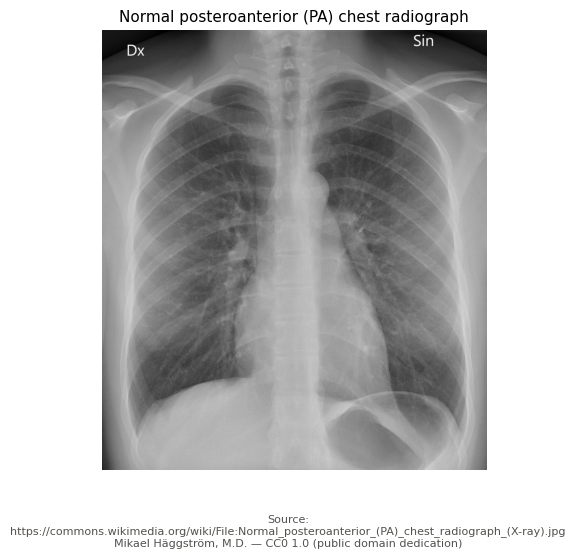


QUESTION
Describe the visible findings in this image. Do not provide a definitive diagnosis.

MODEL OUTPUT
------------------------------------------------------------------------------
The image shows a full-length chest x-ray of a patient. The patient's lungs
appear to be clear, with no signs of any abnormalities. The ribs are visible,
and the spine is also visible. The heart is located in the center of the
image, and the trachea is visible. The image is well-exposed, and the details
of the lungs and other structures are clearly visible.
------------------------------------------------------------------------------
82 tokens in 12.1s | image 1007x1152 | prompt 1858 tokens


In [16]:
result_1 = run_analysis(MEDICAL_IMAGES[0], MODEL, PROCESSOR, CFG)

# 9. Public medical image 2 — chest radiograph with lobar pneumonia

**Source:** [Wikimedia Commons — X-ray of lobar pneumonia](https://commons.wikimedia.org/wiki/File:X-ray_of_lobar_pneumonia.jpg)
· Mikael Häggström, M.D. · **CC0 1.0** (public domain dedication)

Same modality, abnormal study. Pairing it with §8 is what makes the comparison meaningful:
if the model produces similar descriptions for a normal and an abnormal chest film, it is
pattern-matching on "chest X-ray" rather than looking at *this* image — and you can only
see that by holding the modality constant and changing the finding.

Chest radiograph showing lobar pneumonia


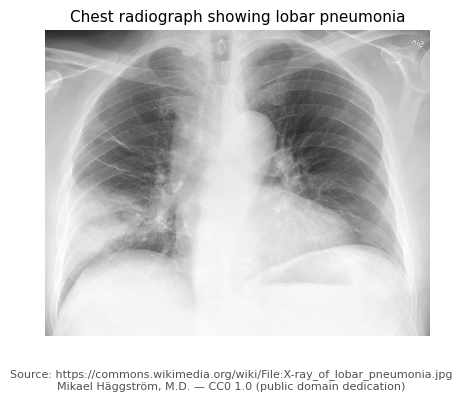


QUESTION
What abnormalities, if any, are visible in this chest radiograph? Describe their location and appearance without giving a diagnosis.

MODEL OUTPUT
------------------------------------------------------------------------------
The chest radiograph shows a full, expanded lung field with a prominent hilum
and a prominent costophrenic angle. The left lung field is also expanded, but
it appears slightly less expanded than the right lung field. The right lung
field is expanded, but it appears slightly less expanded than the left lung
field. The mediastinum is normal, and the heart is not visible. The trachea is
not visible, and the esophagus is not visible. The ribs are expanded, and the
costal cartilages are not visible. The pleural lines are not visible. The
image is clear, and there are no shadows or other abnormalities.
------------------------------------------------------------------------------
133 tokens in 15.1s | image 1152x916 | prompt 1867 tokens


In [17]:
result_2 = run_analysis(MEDICAL_IMAGES[1], MODEL, PROCESSOR, CFG)

### 9b. Optional third image — a different modality

**Source:** [Wikimedia Commons — Radiograph of Barton's fracture](https://commons.wikimedia.org/wiki/File:Radiograph_of_Barton%27s_fracture.jpg)
· Mikael Häggström, M.D. · **CC0 1.0**

A wrist radiograph, included to test whether the model correctly identifies the
**anatomical region** — the most basic competence, and the one whose failure would
invalidate everything above it.

Radiograph of a Barton's fracture (wrist)


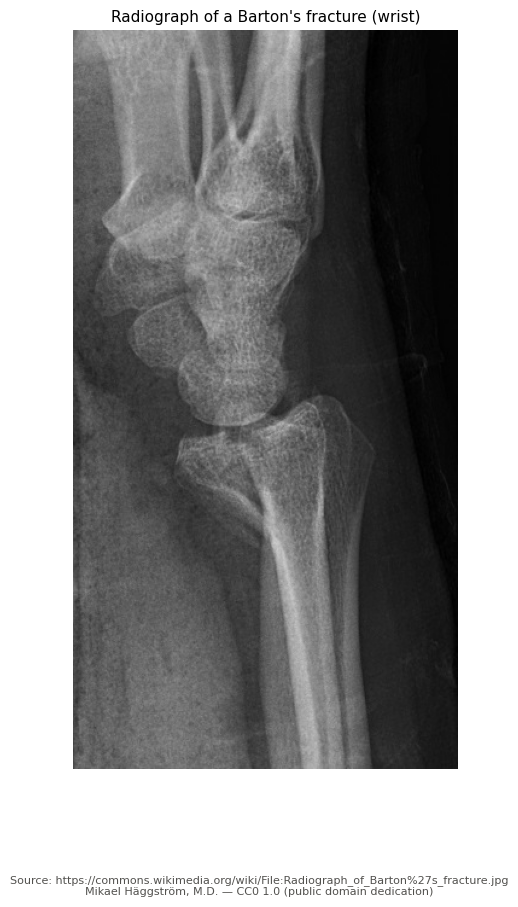


QUESTION
Describe what anatomical region this radiograph shows and any visible bony abnormality. Do not provide a definitive diagnosis.

MODEL OUTPUT
------------------------------------------------------------------------------
The radiograph shows the wrist region. The bones of the forearm are visible,
including the radius and ulna. The radius is the larger of the two bones and
is located on the thumb side of the forearm. The ulna is located on the other
side of the forearm and is smaller than the radius. The bones of the wrist are
also visible, including the carpals. The carpals are the small bones that form
the wrist joint. The bones of the hand are also visible, including the
metacarpals. The metacarpals are the long bones that form the palm of the
hand. The bones of the fingers are also visible, including the phalanges. The
phalanges are the small bones that form the fingers.
------------------------------------------------------------------------------
149 tokens in 11.5s | ima

In [18]:
result_3 = run_analysis(MEDICAL_IMAGES[2], MODEL, PROCESSOR, CFG)

### Asking your own question

The same function, with any question and any image — a URL, a local path, or an uploaded
file. This is the reusable interface requirement (§7) in use.

In [19]:
my_question = "Is the cardiac silhouette within normal limits in this image? Explain what you can and cannot assess."

print(analyze_medical_image(MEDICAL_IMAGES[0]['url'], my_question,
                            MODEL, PROCESSOR, CFG))

Yes, the cardiac silhouette is within normal limits in this image.


# 10. Compare outputs

One row per image: the prompt, the model's response, and a column for observed limitations.

**The limitations column is deliberately left empty for you to fill in.** Judging whether
a model hallucinated a finding requires looking at the image and knowing what is actually
there; a script that auto-filled that column would be inventing exactly the kind of
unsupported claim this project exists to avoid.

Things worth looking for as you read the three outputs:

- Did it name the correct **modality** and **anatomical region** each time?
- Did the normal film (§8) stay normal, or did it acquire findings?
- Do §8 and §9 differ in the way the images differ, or are they near-identical prose?
- Did it hedge, or did it slip into a definitive diagnosis despite rules 2 and 3?
- Did it invent age, sex or clinical history (rule 9)?

In [20]:
def comparison_table(results: list[dict[str, Any]]):
    """Section 10: image, prompt, response, observed limitations - side by side.

    The 'observed limitations' column is filled in by the reader after looking at the
    outputs. It is deliberately not auto-generated: judging whether a model hallucinated a
    finding requires looking at the image, and a script that pretended to do that would be
    inventing exactly the kind of unsupported claim this project is about avoiding.
    """
    rows = []
    for r in results:
        rows.append({
            "image": r["title"],
            "prompt": textwrap.shorten(r["question"], 70, placeholder=" ..."),
            "model response": textwrap.shorten(r.get("answer", ""), 220, placeholder=" ..."),
            "tokens / seconds": f"{r.get('generated_tokens', 0)} / {r.get('seconds', 0)}",
            "observed limitations": "",   # fill in after reading the full outputs
        })
    try:
        import pandas as pd
        df = pd.DataFrame(rows).set_index("image")
        with pd.option_context("display.max_colwidth", 240):
            return df
    except ImportError:
        return rows

In [21]:
comparison_table([result_1, result_2, result_3])

,prompt,model response,tokens / seconds,observed limitations
image,,,,
Normal posteroanterior (PA) chest radiograph,Describe the visible findings in this image. D...,The image shows a full-length chest x-ray of a...,82 / 12.1,
Chest radiograph showing lobar pneumonia,"What abnormalities, if any, are visible in thi...","The chest radiograph shows a full, expanded lu...",133 / 15.1,
Radiograph of a Barton's fracture (wrist),Describe what anatomical region this radiograp...,The radiograph shows the wrist region. The bon...,149 / 11.5,


# 11. Sample outputs

**No sample outputs are written into this notebook.** Every model response in §8–§10 is
produced when *you* execute the cells, on your hardware, with these weights. Nothing here
is transcribed from a previous run.

That is a deliberate choice, and it is the same principle as §10's empty column: a
notebook that ships pre-written "sample outputs" is indistinguishable from one that
fabricated them, and in a clinical context fabricated findings are precisely the failure
mode the whole project is about.

Expected shape of a response, given the prompt structure in §6 — a *format* expectation,
not a claim about what the model will say:

```
Image type: <what kind of study it appears to be>
Visible features: <objective description of what can be seen>
Preliminary impression: <cautious, hedged, non-diagnostic>
Uncertainty: <what is unclear or cannot be assessed>
Recommendation: <review by a qualified radiologist>
```

A 2.25 B model will not always honour that structure. Where it does not, that is itself a
finding worth recording in §10 — it is evidence about how far a system prompt alone can
be trusted as a safety control.

In [22]:
def save_outputs(results: list[dict[str, Any]], cfg: Config = CFG,
                 runtime: dict[str, Any] = None, model=None,
                 out_dir: str | Path = "outputs", download: bool = False) -> dict[str, Path]:
    """Persist the generated outputs together with everything needed to reproduce them.

    A recorded answer is only meaningful alongside the model that produced it, the dtype
    it ran in and the decoding settings - so the manifest carries the *actual* loaded
    checkpoint (which may be the fallback, not the one requested), the library versions
    and the hardware, not just the text.
    """
    import json
    import platform
    from datetime import datetime, timezone

    import transformers

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    runtime = runtime or {}

    actual_model = cfg.model_id
    if model is not None:
        actual_model = getattr(model, "name_or_path", None) or \
            getattr(model.config, "_name_or_path", cfg.model_id)

    manifest = {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "model_requested": cfg.model_id,
        "model_actually_loaded": actual_model,
        "transformers": transformers.__version__,
        "torch": torch.__version__,
        "python": platform.python_version(),
        "device": str(runtime.get("device_name", "unknown")),
        "dtype": str(runtime.get("dtype", "unknown")),
        "load_in_4bit": cfg.load_in_4bit,
        "do_image_splitting": cfg.do_image_splitting,
        "generation": {"max_new_tokens": cfg.max_new_tokens, "do_sample": cfg.do_sample},
        "max_image_px": cfg.max_image_px,
        "system_prompt": SYSTEM_PROMPT,
        "results": [
            {k: v for k, v in r.items() if k in
             ("key", "title", "url", "page", "author", "license", "question",
              "answer", "seconds", "generated_tokens", "prompt_tokens", "image_size")}
            for r in results
        ],
    }

    paths = {"json": out_dir / "sample_outputs.json", "md": out_dir / "sample_outputs.md"}
    paths["json"].write_text(json.dumps(manifest, indent=2, ensure_ascii=False),
                             encoding="utf-8")

    lines = [
        "# Sample outputs", "",
        f"Generated {manifest['generated_at_utc']} · model "
        f"`{manifest['model_actually_loaded']}` · {manifest['device']} · "
        f"{manifest['dtype']} · transformers {manifest['transformers']}", "",
        "> Educational and research use only. Not a medical device. These outputs are "
        "raw model text, reproduced exactly as generated - including any errors.", "",
    ]
    for r in manifest["results"]:
        lines += [
            f"## {r.get('title', r.get('key', 'image'))}", "",
            f"- **Source:** {r.get('page', '')}",
            f"- **Attribution:** {r.get('author', '')} — {r.get('license', '')}",
            f"- **Image URL:** {r.get('url', '')}",
            f"- **Generation:** {r.get('generated_tokens', '?')} tokens in "
            f"{r.get('seconds', '?')} s (prompt {r.get('prompt_tokens', '?')} tokens)", "",
            f"**Question:** {r.get('question', '')}", "",
            "**Model output:**", "", "```text", str(r.get("answer", "")).strip(), "```", "",
        ]
    paths["md"].write_text("\n".join(lines), encoding="utf-8")

    for name, path in paths.items():
        print(f"  wrote {path}")

    if download:                       # convenience when running in Colab
        try:
            from google.colab import files
            for path in paths.values():
                files.download(str(path))
        except Exception:
            print("  (not running in Colab - files are on the runtime filesystem)")
    return paths

In [23]:
# Writes outputs/sample_outputs.json and outputs/sample_outputs.md.
# Set download=True to pull them straight out of Colab.
paths = save_outputs([result_1, result_2, result_3], CFG, RUNTIME, MODEL,
                     out_dir='outputs', download=False)

print()
print(open(paths['md'], encoding='utf-8').read()[:1500])

  wrote outputs/sample_outputs.json
  wrote outputs/sample_outputs.md

# Sample outputs

Generated 2026-09-03T14:11:17+00:00 · model `HuggingFaceTB/SmolVLM-Instruct` · Tesla T4 · torch.bfloat16 · transformers 4.57.6

> Educational and research use only. Not a medical device. These outputs are raw model text, reproduced exactly as generated - including any errors.

## Normal posteroanterior (PA) chest radiograph

- **Source:** https://commons.wikimedia.org/wiki/File:Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg
- **Attribution:** Mikael Häggström, M.D. — CC0 1.0 (public domain dedication)
- **Image URL:** https://upload.wikimedia.org/wikipedia/commons/a/a1/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg
- **Generation:** 82 tokens in 12.1 s (prompt 1858 tokens)

**Question:** Describe the visible findings in this image. Do not provide a definitive diagnosis.

**Model output:**

```text
The image shows a full-length chest x-ray of a patient. The patient's lung

# 12. Limitations and ethical considerations

## 12.1 Limitations

**1. A general-purpose VLM is not a diagnostic system.** SmolVLM was trained on general
web image–text pairs. It has seen radiographs the way the internet contains radiographs —
in articles, textbook scans and teaching sites — not as a supervised diagnostic curriculum
with expert-verified labels. Diagnostic imaging systems that reach clinical use are trained
on large, curated, radiologist-labelled datasets and validated against defined endpoints.
None of that applies here. The gap is one of *kind*, not degree, and it cannot be closed by
prompt engineering.

**2. Image quality drives the output.** Radiographs vary in exposure, projection (PA vs AP
vs lateral), rotation, inspiration, patient positioning, and the presence of lines, tubes
and jewellery — all of which change appearance without changing pathology. This pipeline
also downscales to ≤ 1152 px and the model tiles at 384 px, so fine detail that a
radiologist reads at full diagnostic resolution — a subtle pneumothorax line, an early
interstitial pattern, a hairline fracture — may simply not survive to reach the model.

**3. Hallucination is possible and likely.** VLMs generate plausible continuations, and
plausibility is not truth. Asked to describe findings, a model will produce findings.
The most dangerous case is the normal study (§8): a confident description of a
consolidation that is not there reads exactly like a correct description of one that is.
The system prompt reduces this tendency; nothing here eliminates it.

**4. Subtle abnormalities will be missed.** Absence of a reported finding is not evidence
of absence. Small nodules, early interstitial change, subtle fractures and slow interval
change are difficult for expert humans at full resolution, and this pipeline has neither
the resolution, the training, nor the prior imaging for comparison.

**5. Outputs may simply be wrong.** Both directions matter. A false positive triggers
unnecessary anxiety and investigation; a false negative offers false reassurance. In a
clinical pathway the second is usually the more harmful, and it is the one a fluent,
confident-sounding "no acute abnormality" produces most easily.

**6. Public images do not represent clinical reality.** The three images here are
well-exposed, correctly positioned, cleanly digitised teaching examples chosen from
Wikimedia Commons — the top of the quality distribution. They carry no demographic
metadata, so nothing here says anything about performance across age, sex, body habitus,
ethnicity, comorbidity, scanner vendor, or the portable bedside films that make up much of
real inpatient imaging. Three curated images are an illustration, not an evaluation.

**7. There is no quantitative evaluation in this notebook.** Requirement 5 asks for
inference on two images and that is what is delivered — but two or three qualitative
examples cannot support any claim about accuracy. A real assessment needs a labelled test
set, a defined task, agreed metrics, and comparison against radiologist ground truth.
No accuracy claim is made anywhere in this project, and none should be inferred from a
plausible-looking output.

**8. A system prompt is a request, not a guarantee.** Rules 1–10 in §6 bias generation;
they do not constrain it. A 2.25 B model may ignore the required structure, drop the
hedging, or state a diagnosis despite being told not to. Treat the prompt as a soft
mitigation, and read §8–§10 as a test of whether it held rather than proof that it did.

**9. Small checkpoints may return nothing at all.** An end-to-end test of this exact
pipeline on `SmolVLM-256M-Instruct` (CPU) loaded the model, preprocessed a real radiograph
and generated 67 tokens — which decoded to an **empty string**. The most likely cause is
that a ~1,800-token system prompt crowds out the response in a 256M model. The pipeline
now detects this and says so rather than printing nothing, but it is a concrete reminder
that the safety prompt is not free: it consumes context, and on a small model it can
consume the answer. If you drop to a smaller checkpoint, shorten the system prompt too.

**10. This must not replace a qualified professional.** Interpretation of medical imaging
is a regulated clinical activity performed by trained radiologists and physicians who have
the patient's history, prior imaging, laboratory results and examination findings — none
of which a single image contains.

## 12.2 Ethical considerations

**Not a medical device.** Software intended to inform clinical decisions is regulated
(FDA, EU MDR, UKCA). This notebook has no such clearance, no validation, and no quality
management system behind it. Deploying it in a care pathway would be both unsafe and, in
most jurisdictions, unlawful.

**Automation bias is the realistic harm.** The plausible failure mode is not someone
replacing a radiologist with a 2.25 B model. It is a clinician, student or patient reading
a fluent, well-structured, professional-sounding paragraph and letting it anchor their
judgement. Fluency reads as competence, and this model is far more fluent than it is
competent. That is precisely why §6 forces uncertainty into its own labelled section and
why no sample outputs are pre-written into this notebook.

**Patient privacy.** The images used here are CC0 teaching images with no identifiable
patient data. Real clinical images are protected health information: DICOM headers carry
identifiers, and burned-in annotations can carry names and dates that de-identification of
the header alone will not remove. Sending such images to any third-party or hosted model
is a disclosure event. Everything in this notebook runs locally on the Colab runtime, and
that property should be preserved in any extension.

**Bias and equity.** Performance of imaging models varies across demographic groups, and
publicly available teaching images are not a representative sample of any population.
Nothing in this project measures that, so nothing in it should be assumed to be equitable
across groups.

**Consent and provenance.** Every image here is CC0, attributed to its author, with its
source page linked in §8, §9 and §9b. Medical images sourced from search engines or
scraped datasets frequently lack clear licensing or patient consent, and using them —
particularly for training — raises real ethical and legal problems.

**Honest reporting.** No model output in this project is fabricated, no accuracy figure is
claimed, and the comparison table's limitations column is left for a human to complete.
In a clinical context, an overstated capability claim is itself a safety issue.

---

# 13. Conclusion

**Model.** SmolVLM-Instruct (`HuggingFaceTB/SmolVLM-Instruct`), 2.25 B parameters, a SigLIP
vision encoder with a SmolLM2 text decoder, Apache-2.0 and ungated.

**Why it suits free Colab.** Roughly 4.5 GB of fp16 weights against a T4's ~15 GB leaves
about 10 GB for activations, KV cache and image tiles — no quantisation required, no
out-of-memory risk mid-demonstration, and no access token needed for a marker to reproduce
it. Larger options were rejected on concrete grounds rather than by reflex: Phi-3-vision is
~8.3 GB of weights for no benefit on single-image questions, Qwen2-VL-2B is comparable in
size but adds a version-sensitive preprocessing dependency, and Florence-2 was ruled out on
capability — it is driven by task tokens and cannot follow a clinical system prompt at all.

**Memory optimisations used.** Hardware-aware dtype selection (bf16 where
`torch.cuda.is_bf16_supported()`, fp16 on a T4, fp32 on CPU); `device_map="auto"` via
Accelerate; `low_cpu_mem_usage=True` to protect *host* RAM during loading; image
downscaling to bound the visual sequence length; and an optional, guarded 4-bit NF4 path
that is deliberately left off because the model already fits comfortably and quantisation
would cost quality for nothing.

**What the pipeline does.** `analyze_medical_image(image, question)` takes a PIL image, a
path or a URL, applies a clinical system prompt through the model's chat template —
verified to actually render the system role rather than silently discard it — runs greedy
decoding for reproducibility, and returns cleaned text with optional timing metadata. It
handles unreadable images, empty questions, missing models, CUDA OOM, and the HTTP 403
that Wikimedia returns to default user-agents.

**Key limitations.** It is a general-purpose describer, not a diagnostic system; it can
hallucinate findings and miss subtle ones; three curated public images demonstrate the
pipeline but evaluate nothing; the system prompt is a soft mitigation rather than a
constraint; and the outputs must never inform real clinical decisions.

**What would make it genuinely useful.** A labelled evaluation set with radiologist ground
truth and reported metrics; a medically fine-tuned VLM such as a LLaVA-Med-class model
instead of a general-purpose one; full-resolution or region-of-interest inference rather
than a global downscale; a refusal/abstention mechanism for low-confidence cases; and
measurement across demographic subgroups. Each of those is a substantial project, and
naming them is the honest way to describe the distance between this demonstration and
anything clinically meaningful.